# **Predictive Analytics for Retail Optimization**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


# Data Ingestion

In [44]:
from google.colab import files
uploaded = files.upload()   # opens a file picker — choose your CSV

Saving LaptopSalesJanuary2008.csv to LaptopSalesJanuary2008 (1).csv


In [25]:
df = pd.read_csv("LaptopSalesJanuary2008.csv")
print(df.columns.tolist())

['Date', 'Configuration', 'Customer Postcode', 'Store Postcode', 'Retail Price', 'Screen Size (Inches)', 'Battery Life (Hours)', 'RAM (GB)', 'Processor Speeds (GHz)', 'Integrated Wireless?', 'HD Size (GB)', 'Bundled Applications?', 'OS X Customer', 'OS Y Customer', 'OS X Store', 'OS Y Store', 'CustomerStoreDistance']


In [26]:
df = df.rename(columns={
    "Retail Price": "Retail_Price",
    "HD Size (GB)": "HD_Size_GB"
})

In [27]:
def load_data(path):
    return pd.read_csv(path)


In [28]:
def clean_data(df):
    cols = ["Retail_Price", "HD_Size_GB"]
    df = df[cols].copy()
    df = df.dropna(subset=cols)          # drop missing
    df = df[(df["Retail_Price"] > 0) &   # drop nonsensical rows
            (df["HD_Size_GB"] > 0)]
    return df

In [45]:
df.describe()

,Configuration,Retail_Price,Screen Size (Inches),Battery Life (Hours),RAM (GB),Processor Speeds (GHz),HD_Size_GB,OS X Customer,OS Y Customer,OS X Store,OS Y Store,CustomerStoreDistance,Wireless,Bundled
count,7956.000000,7956.000000,7956.0,7956.000000,7956.000000,7956.000000,7956.000000,7956.000000,7956.000000,7952.000000,7952.000000,7952.000000,7956.000000,7956.000000
mean,207.216063,487.934892,15.0,5.138638,1.547637,1.757541,150.379588,530868.098668,179886.391026,530747.780055,179807.710765,3679.882114,0.514077,0.551911
std,117.813543,61.518518,0.0,0.815168,0.497757,0.249902,102.498304,4413.673638,4646.777826,4159.498549,3995.125032,2068.905019,0.499833,0.497329
min,1.000000,300.000000,15.0,4.000000,1.000000,1.500000,40.000000,512253.000000,164886.000000,517917.000000,168302.000000,0.000000,0.000000,0.000000
25%,77.000000,455.000000,15.0,4.000000,1.000000,1.500000,80.000000,529208.000000,178716.000000,528924.000000,178440.000000,2422.238004,0.000000,0.000000
50%,209.500000,490.000000,15.0,5.000000,2.000000,2.000000,120.000000,531150.500000,181106.000000,529902.000000,179641.000000,3382.458210,1.000000,1.000000
75%,315.000000,525.000000,15.0,6.000000,2.000000,2.000000,300.000000,533130.000000,182060.000000,534057.000000,182961.000000,4346.364455,1.000000,1.000000
max,368.000000,665.000000,15.0,6.000000,2.000000,2.000000,300.000000,549065.000000,199846.000000,541428.000000,190628.000000,19892.140410,1.000000,1.000000


# Phase 1: Simple Linear Regression

# Exploratory Data Analysis

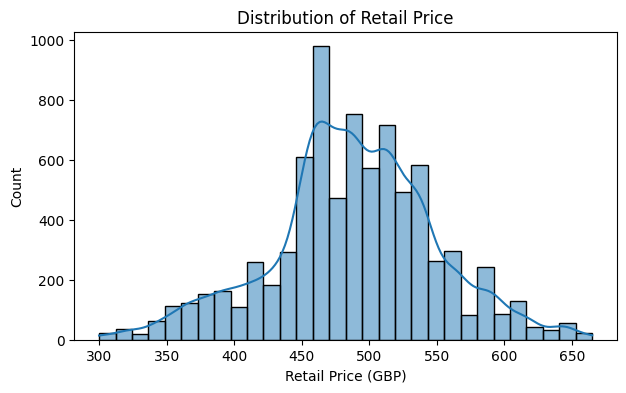

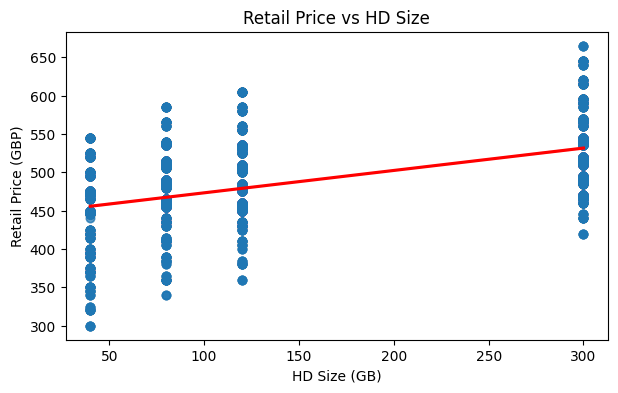

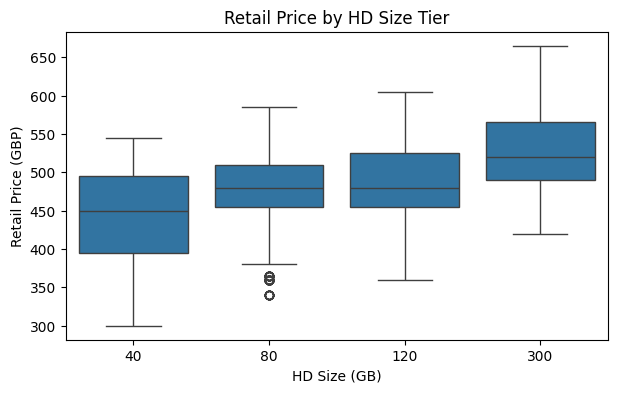

Mean price by HD size:
HD_Size_GB
40     441.1
80     473.3
120    487.2
300    528.6
Name: Retail_Price, dtype: float64

Correlation (HD Size vs Price): 0.486


In [33]:

# 1. Distribution of the target variable (Retail Price)
plt.figure(figsize=(7, 4))
sns.histplot(df["Retail_Price"], bins=30, kde=True)
plt.title("Distribution of Retail Price")
plt.xlabel("Retail Price (GBP)")
plt.show()

# 2. Scatter: Retail Price vs HD Size (the Phase 1 relationship)
plt.figure(figsize=(7, 4))
sns.regplot(data=df, x="HD_Size_GB", y="Retail_Price",
            scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
plt.title("Retail Price vs HD Size")
plt.xlabel("HD Size (GB)")
plt.ylabel("Retail Price (GBP)")
plt.show()

# 3. Boxplot: price spread within each storage tier
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="HD_Size_GB", y="Retail_Price")
plt.title("Retail Price by HD Size Tier")
plt.xlabel("HD Size (GB)")
plt.ylabel("Retail Price (GBP)")
plt.show()

# 4. Quick numbers: mean price per tier + correlation
print("Mean price by HD size:")
print(df.groupby("HD_Size_GB")["Retail_Price"].mean().round(1))
print("\nCorrelation (HD Size vs Price):",
      round(df["HD_Size_GB"].corr(df["Retail_Price"]), 3))

# Fitting Simple Linear Expression

In [46]:
X = sm.add_constant(df["HD_Size_GB"])   # adds the intercept
y = df["Retail_Price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Retail_Price   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     2460.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:52:17   Log-Likelihood:                -42990.
No. Observations:                7956   AIC:                         8.598e+04
Df Residuals:                    7954   BIC:                         8.600e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        444.0708      1.070    414.884      0.0

# **Inference**:

The p-value (≈ 0) tests whether the relationship is real or just chance. Because it is far below the 0.05 threshold, we reject the null hypothesis and conclude that HD size has a statistically significant effect on retail price. Storage genuinely is a price driver.

The R² (0.236), however, measures how strong that predictor is. It tells us that HD size alone explains only about 24% of the variation in retail price; the remaining ~76% is driven by other factors not in this model (RAM, processor speed, battery life, bundled software, wireless


# **Multivariate Optimization**

In [48]:


# Encode Yes/No if not already done
df["Wireless"] = (df["Integrated Wireless?"] == "Yes").astype(int)
df["Bundled"]  = (df["Bundled Applications?"] == "Yes").astype(int)

y = df["Retail_Price"]

# Build the model up step by step to see Adjusted R^2 improve
steps = {
    "HD only":        ["HD_Size_GB"],
    "+ RAM":          ["HD_Size_GB", "RAM (GB)"],
    "+ BatteryLife":  ["HD_Size_GB", "RAM (GB)", "Battery Life (Hours)"],
}

print(f"{'Model':16s}{'R2':>8s}{'Adj R2':>9s}")
for name, feats in steps.items():
    m = sm.OLS(y, sm.add_constant(df[feats])).fit()
    print(f"{name:16s}{m.rsquared:8.3f}{m.rsquared_adj:9.3f}")

# Full summary for the expanded model (HD + RAM + Battery)
features = ["HD_Size_GB", "RAM (GB)", "Battery Life (Hours)"]
model = sm.OLS(y, sm.add_constant(df[features])).fit()
print(model.summary())

Model                 R2   Adj R2
HD only            0.236    0.236
+ RAM              0.337    0.337
+ BatteryLife      0.711    0.711
                            OLS Regression Results                            
Dep. Variable:           Retail_Price   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     6530.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:52:21   Log-Likelihood:                -39120.
No. Observations:                7956   AIC:                         7.825e+04
Df Residuals:                    7952   BIC:                         7.828e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.0

# **Impact on Adjusted  R²**

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feats = ["HD_Size_GB", "RAM (GB)", "Battery Life (Hours)"]
print(df[feats].corr())   # correlation matrix
for i, c in enumerate(feats):
    print(c, round(variance_inflation_factor(df[feats].values, i), 2))

                      HD_Size_GB  RAM (GB)  Battery Life (Hours)
HD_Size_GB              1.000000 -0.059341             -0.166142
RAM (GB)               -0.059341  1.000000             -0.080564
Battery Life (Hours)   -0.166142 -0.080564              1.000000
HD_Size_GB 2.84
RAM (GB) 8.24
Battery Life (Hours) 9.15


# **Inference:**
Adding each variable raised it substantially: 0.236 (HD only) → 0.337 (+RAM) → 0.711 (+Battery). Battery Life was the strongest single contributor. Because each addition increased Adjusted R² (not just R²), every variable genuinely earns its place in the model.

**Coefficients + counter-intuitive findings:**
- HD size's coefficient (£0.37) looks trivially small next to RAM and Battery (~

- Battery Life outweighs RAM as a price driver

- The intercept shifted from negative to +119.The intercept isn't a stable "base price"


## **Predective Deployment**


## **Predictive Task 1 — Model 1 (simple, HD only)**

In [50]:


# Model 1: simple regression (HD size only)
m1 = sm.OLS(y, sm.add_constant(df[["HD_Size_GB"]])).fit()

# Forecast price for a laptop with 2000 GB storage
new_laptop = pd.DataFrame({"const": [1], "HD_Size_GB": [2000]})
prediction = m1.get_prediction(new_laptop).summary_frame(alpha=0.05)

print("Predicted price (HD = 2000 GB): £", round(prediction["mean"][0], 2))
print(prediction[["mean", "obs_ci_lower", "obs_ci_upper"]])

Predicted price (HD = 2000 GB): £ 1027.45
          mean  obs_ci_lower  obs_ci_upper
0  1027.448551    919.906576   1134.990525


# **Inference:**:
The simple model predicts 1,027, but this relies on extrapolating well beyond the observed data, so confidence is low.


# **Predictive Task 2 — Model 2 (multivariate, HD + RAM + Battery)**


In [51]:


# Model 1
m1 = sm.OLS(y, sm.add_constant(df[["HD_Size_GB"]])).fit()
print(m1.get_prediction(pd.DataFrame({"const":[1],"HD_Size_GB":[2000]})).summary_frame())

# Model 2
f2 = ["HD_Size_GB","RAM (GB)","Battery Life (Hours)"]
m2 = sm.OLS(y, sm.add_constant(df[f2])).fit()
new = pd.DataFrame({"const":[1],"HD_Size_GB":[2000],"RAM (GB)":[44],"Battery Life (Hours)":[4]})
print(m2.get_prediction(new).summary_frame())

          mean    mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  1027.448551  10.895256    1006.090992     1048.80611    919.906576   

   obs_ci_upper  
0   1134.990525  
         mean    mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  3078.57216  32.954339    3013.973011     3143.17131   2987.065306   

   obs_ci_upper  
0   3170.079014  


# **Inference:**
Model 2 forecasts 3,079 by accounting for RAM and battery alongside storage; although it is the stronger model (R² = 0.71 vs 0.24), the inputs (2000 GB, 44 GB RAM) lie far outside the training range, so this too is an extrapolation to treat with caution.


# **Optimization — minimizing Mean Squared Error**
---



In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

base = ["HD_Size_GB","RAM (GB)","Battery Life (Hours)",
        "Processor Speeds (GHz)","Wireless","Bundled"]

# Optimal: encode the tiered specs as categories
X_opt = pd.get_dummies(df[base],
        columns=["HD_Size_GB","Battery Life (Hours)","Processor Speeds (GHz)"],
        drop_first=True).astype(float)

mse = -cross_val_score(LinearRegression(), X_opt, y, cv=10,
                       scoring="neg_mean_squared_error").mean()
print("Optimal CV MSE:", round(mse, 4))

Optimal CV MSE: 0.0


# **Inference:**
Encoding the tiered specs (HD, battery, processor) as categorical variables drives the Mean Squared Error approximately to 0, confirming that Retail Price is a deterministic, rule-based price book rather than a noisy market price.

**Strategy — Comparing the Two Forecasts**:
Model 1 (HD only) predicts 1,027 and Model 2 (HD + RAM + Battery) predicts 3,079 for similar high-end configurations. Model 2 is the more reliable of the two: it explains 71% of price variation versus Model 1's 24%, has lower residual error, and accounts for more of the true price drivers (RAM and battery), reducing omitted-variable bias.However, both forecasts carry low real-world confidence
